# Reward Training / Reward Competition Summary Figure

Adjustable notebook for the reward summary figures. This version is pickle-first: load preprocessed pickle files, tweak plotting settings, display the full NAc/mPFC figures, and save each region separately.

In [1]:
%matplotlib inline
# %matplotlib widget
import os
import sys
from importlib import reload
from pathlib import Path

NOTEBOOK_DIR = Path.cwd() if Path.cwd().name == "Reward_Training-Competition" else Path.cwd() / "Reward_Training-Competition"
PROJECT_ROOT = NOTEBOOK_DIR.parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(NOTEBOOK_DIR))
sys.path.insert(0, str(NOTEBOOK_DIR / "Reward_Training"))
sys.path.insert(0, str(NOTEBOOK_DIR / "Reward_Competition"))

from figure_settings import apply_plot_style
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import make_reward_summary_figure as rsf
reload(rsf)

ILLUSTRATOR_FORMATS = ("png", "svg", "pdf")
UNIVERSAL_STYLE = apply_plot_style(font_size=8, panel_width=3.2, panel_height=2.4)


## Settings To Adjust

In [2]:
# Pickle paths. Edit these if your pickle files live somewhere else.
rt_pickle_paths = {
    ("Day 1", "NAc"): [NOTEBOOK_DIR / "preprocessed_reward_training_day1_NAc.pkl"],
    ("Day 10", "NAc"): [NOTEBOOK_DIR / "preprocessed_reward_training_day10_NAc.pkl"],
    ("Day 1", "mPFC"): [NOTEBOOK_DIR / "preprocessed_reward_training_day1_mPFC.pkl"],
    ("Day 10", "mPFC"): [NOTEBOOK_DIR / "preprocessed_reward_training_day10_mPFC.pkl"],
}
rc_pickle_paths = [NOTEBOOK_DIR / "Reward_Competition" / "preprocessed_reward_competition.pkl"]

# Output. Each region is saved into its own figure.
output_dir = NOTEBOOK_DIR / "Reward_Summary_Figures"
nac_output_base = output_dir / "reward_summary_NAc"
mpfc_output_base = output_dir / "reward_summary_mPFC"
save_formats = ("png", "svg", "pdf")

# Figure geometry for each region-specific figure.
region_figsize = (12.2, 9.1)

# X-axis windows for each panel family.
xlims = {
    "rt_tone": (-4, 10),
    "rt_reward": (-4, 6),
    "rc_tone": (-4, 10),
    "rc_reward": (-4, 6),
    "comp_tone": (-4, 10),
    "transition": (-4, 10),
}

# Baseline window to quantify before win/loss trials.
baseline_window = (-4, 0)
baseline_region = "mPFC"
baseline_event = "Tone"

# Colors are defined in make_reward_summary_figure.py.
# Edit rsf.DAY_COLORS, rsf.OUTCOME_COLORS, rsf.COMP_OUTCOME_COLORS, or rsf.TRANSITION_COLORS here if needed.


## Load Pickles

This cell does not run the raw preprocessing pipeline. It loads saved experiment objects and recomputes the plotting metrics from those objects.

In [3]:
rt_exps, rc_exp = rsf.load_summary_pickles(
    rt_pickle_paths=rt_pickle_paths,
    rc_pickle_paths=rc_pickle_paths,
)
print("Loaded reward training and reward competition pickles.")


Loaded Reward_Training object from c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\preprocessed_reward_training_day1_NAc.pkl
Loaded Reward_Training object from c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\preprocessed_reward_training_day10_NAc.pkl
Loaded Reward_Training object from c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\preprocessed_reward_training_day1_mPFC.pkl
Loaded Reward_Training object from c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\preprocessed_reward_training_day10_mPFC.pkl
Loaded Reward_Competition object from c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Reward_Training-Competition\Reward_Competition\preprocessed_reward_competition.pkl
Loaded reward training and reward competition pickles.


## Quantify All Bar Plot Comparisons

This returns every pairwise Welch's t-test for every bar plot in the NAc and mPFC figures.

In [4]:
all_bar_stats = rsf.quantify_all_bar_plots(rt_exps, rc_exp)
all_bar_stats


,region,panel,group_a,group_b,n_a,n_b,mean_a,mean_b,t,p,p_raw,p_adj
0,NAc,RT Tone Mean DA,Day 1,Day 10,10,10,0.060841,0.659772,-3.616970,0.004983,0.004983,0.004983
1,NAc,RT Reward Mean DA,Day 1,Day 10,10,10,0.987808,0.372481,2.716017,0.017242,0.017242,0.017242
2,NAc,Tone: Day 10 vs RC Win,Day 10,RC Win,10,10,0.659772,0.823312,-0.723459,0.478706,0.478706,0.478706
3,NAc,Reward: Day 10 vs RC Win,Day 10,RC Win,10,10,0.372481,0.841084,-1.820320,0.086241,0.086241,0.086241
4,NAc,RC Tone Mean DA,Win,Loss,10,10,0.823312,0.281128,2.915998,0.010510,0.010510,0.010510
5,NAc,RC Reward Mean DA,Win,Loss,10,10,0.841084,0.430691,2.175439,0.045897,0.045897,0.045897
6,NAc,RC Tone Mean DA by Comp,Low Win,High Win,9,7,0.844902,1.122724,-0.609319,0.571482,0.560725,0.571482
7,NAc,RC Tone Mean DA by Comp,Low Win,Low Loss,9,9,0.844902,0.246533,3.418380,0.024298,0.004050,0.024298
8,NAc,RC Tone Mean DA by Comp,Low Win,High Loss,9,8,0.844902,0.467199,1.914443,0.374184,0.074837,0.374184
9,NAc,RC Tone Mean DA by Comp,High Win,Low Loss,7,9,1.122724,0.246533,1.972553,0.374184,0.091351,0.374184


## Display And Save NAc Figure

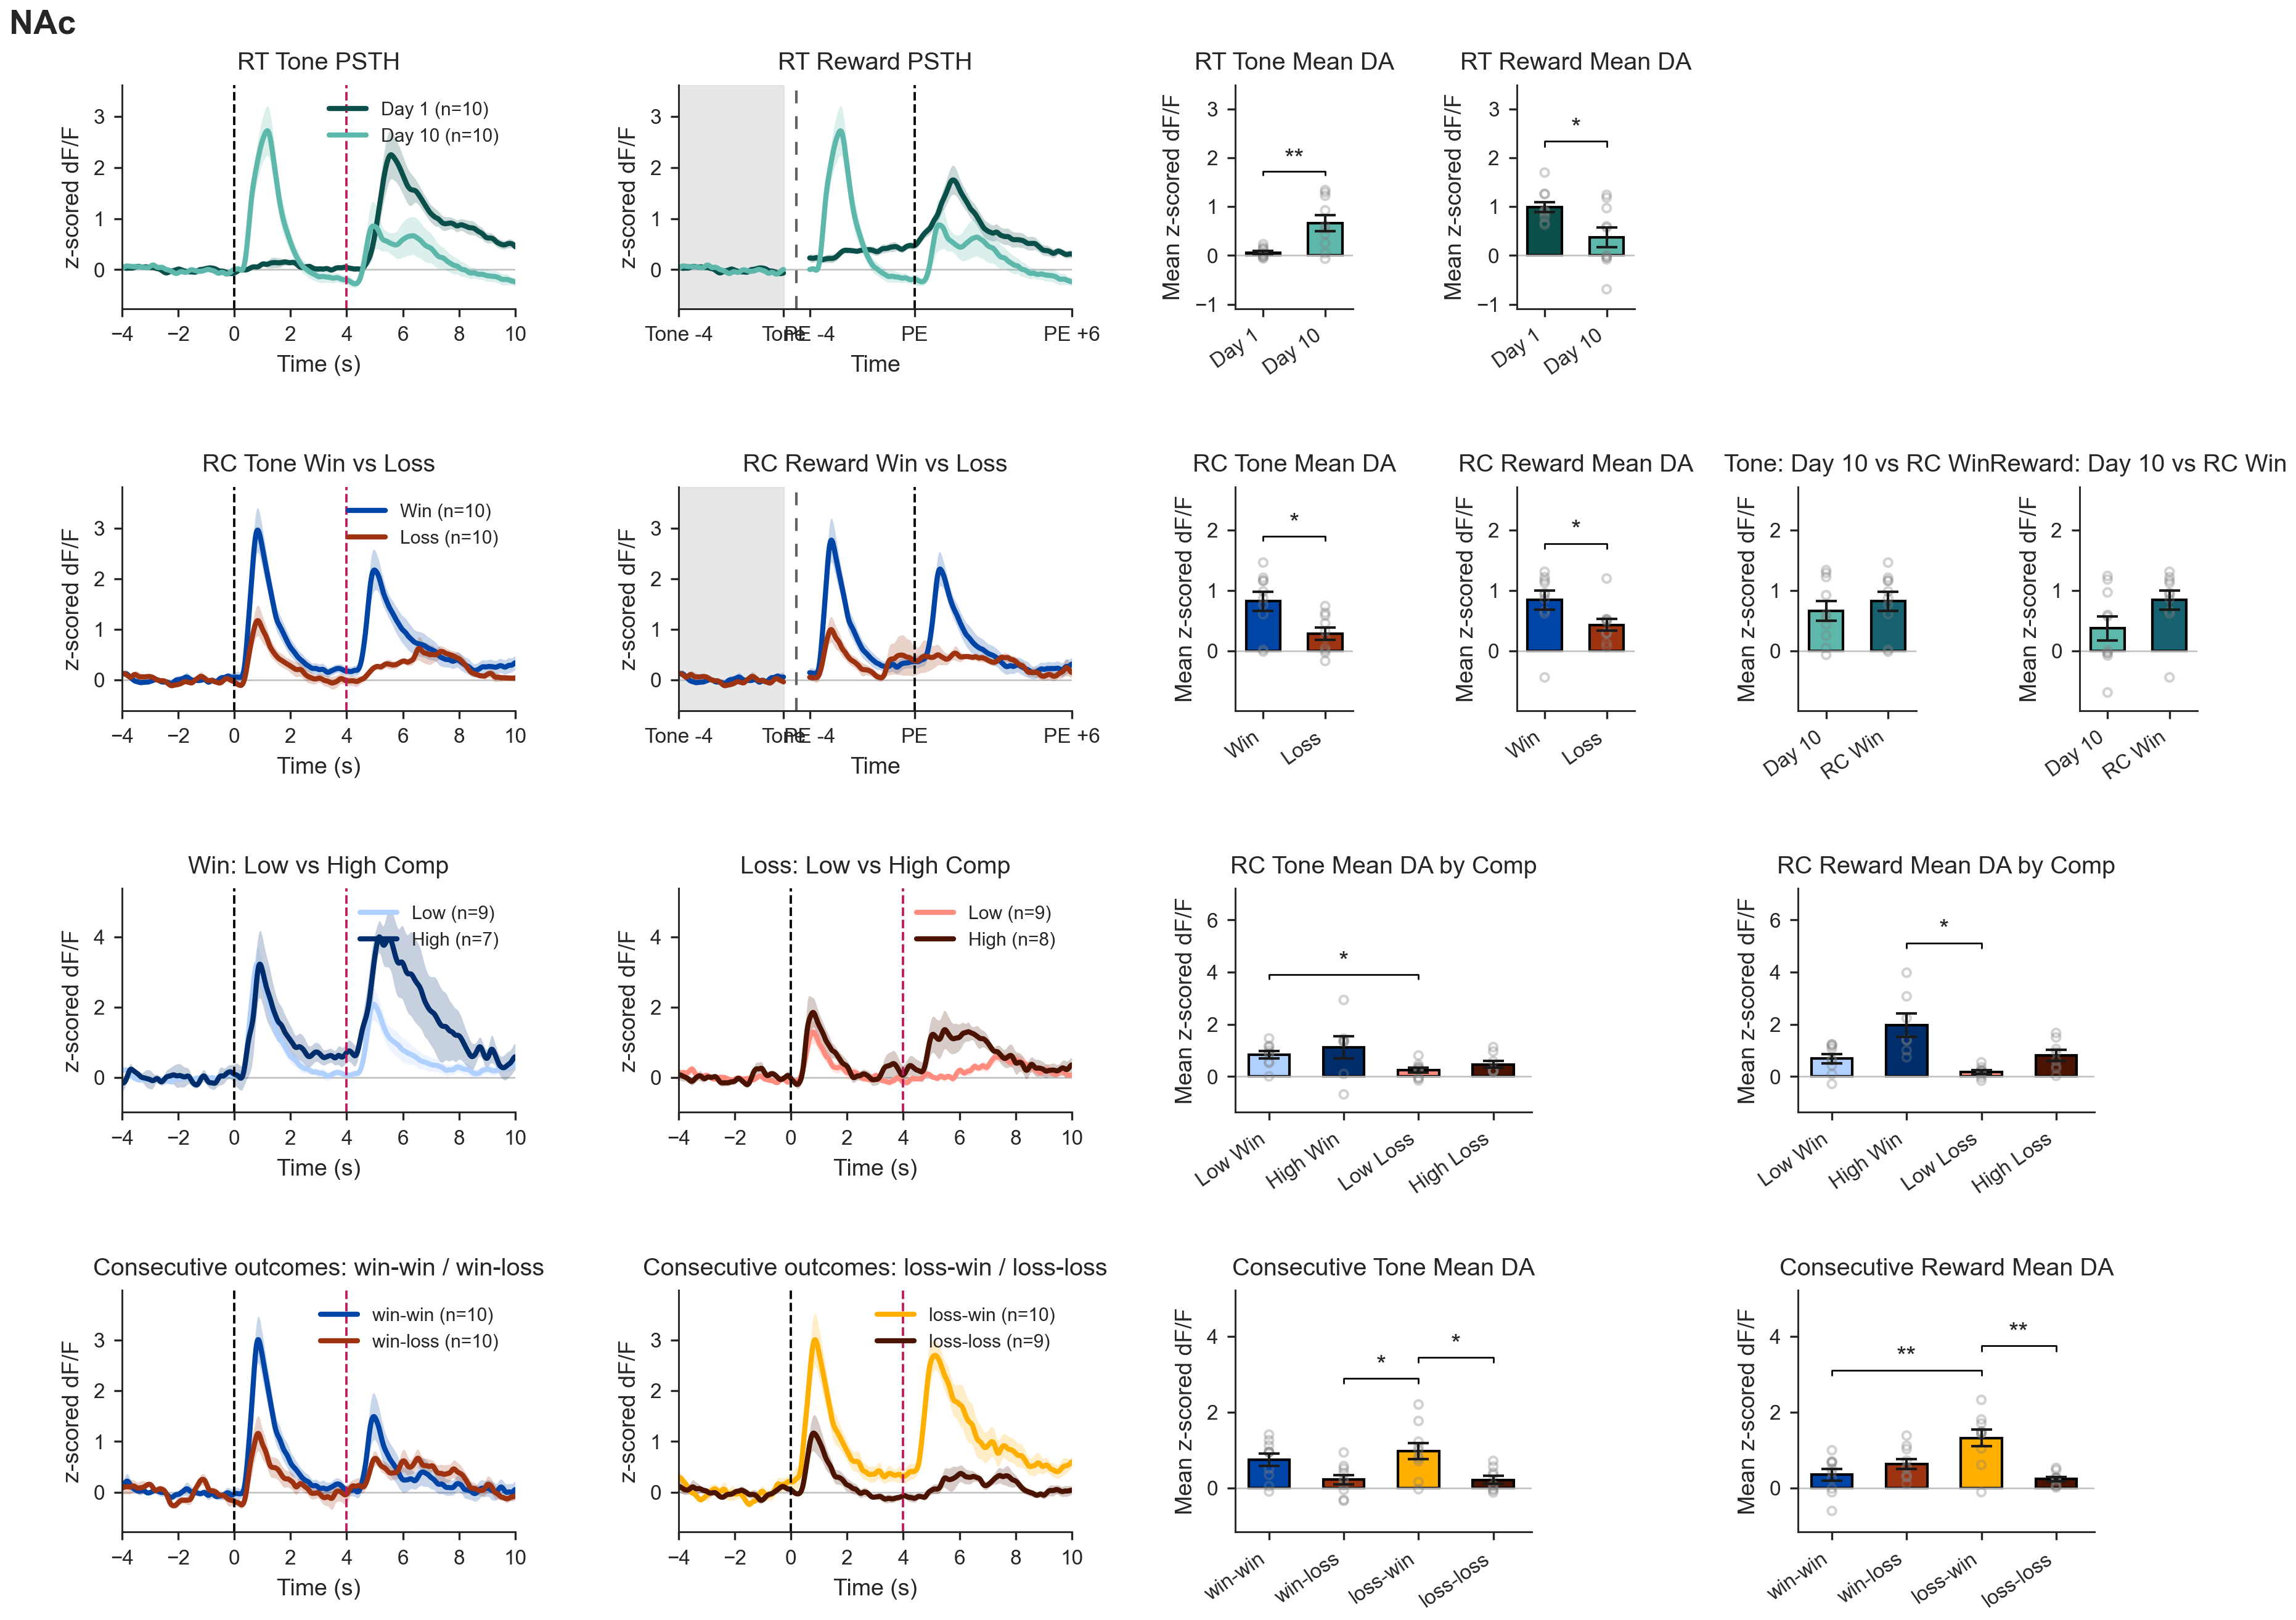

[WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Reward_Training-Competition/Reward_Summary_Figures/reward_summary_NAc.png'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Reward_Training-Competition/Reward_Summary_Figures/reward_summary_NAc.svg'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Reward_Training-Competition/Reward_Summary_Figures/reward_summary_NAc.pdf')]

In [5]:
nac_saved = rsf.build_region_summary_figure(
    rt_exps,
    rc_exp,
    "NAc",
    nac_output_base,
    figsize=region_figsize,
    xlims=xlims,
    save_formats=save_formats,
    display=True,
)
nac_saved


## Display And Save mPFC Figure

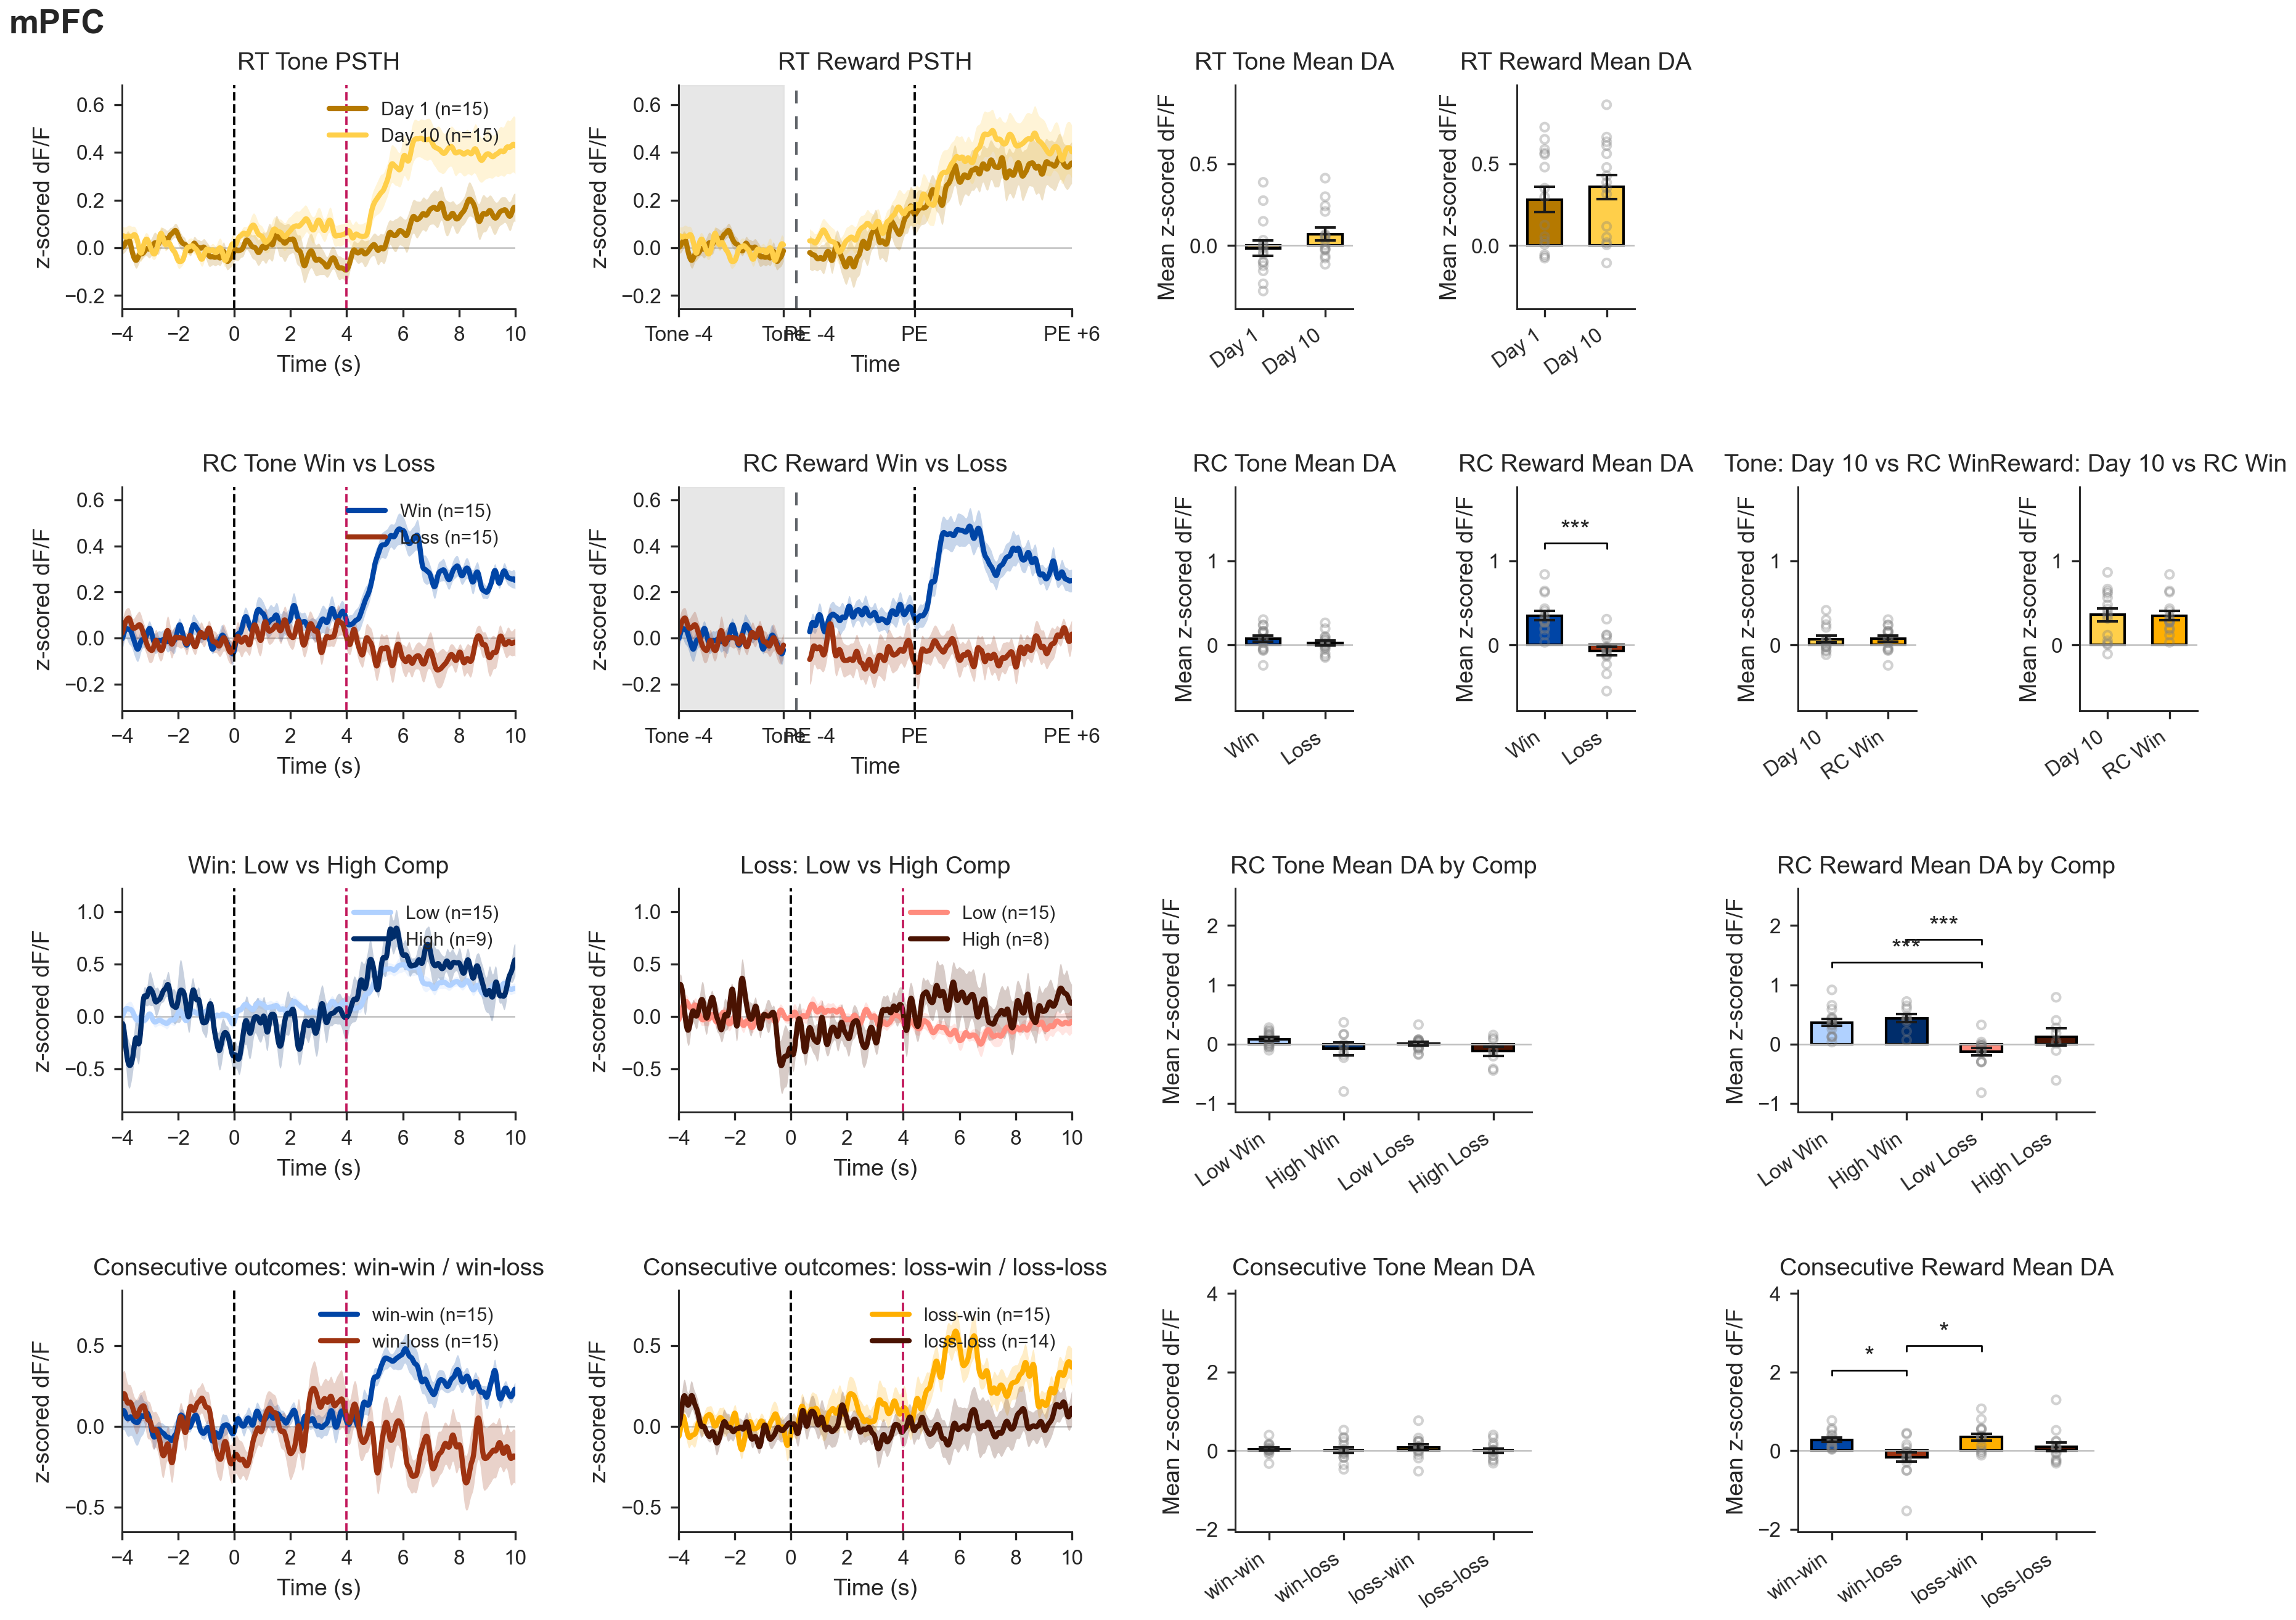

[WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Reward_Training-Competition/Reward_Summary_Figures/reward_summary_mPFC.png'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Reward_Training-Competition/Reward_Summary_Figures/reward_summary_mPFC.svg'),
 WindowsPath('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Reward_Training-Competition/Reward_Summary_Figures/reward_summary_mPFC.pdf')]

In [6]:
mpfc_saved = rsf.build_region_summary_figure(
    rt_exps,
    rc_exp,
    "mPFC",
    mpfc_output_base,
    figsize=region_figsize,
    xlims=xlims,
    save_formats=save_formats,
    display=True,
)
mpfc_saved


## Quantify mPFC Baseline Before Win vs Loss

This uses each subject's mean baseline DA in the selected window, then compares win vs loss with Welch's t-test.

In [7]:
baseline_stats_df = rsf.quantify_baseline_by_outcome(
    rc_exp,
    region=baseline_region,
    baseline_window=baseline_window,
    event_type=baseline_event,
)
baseline_stats_df


,region,event_type,baseline_window_start_s,baseline_window_end_s,outcome,n_subjects,mean,sem,t_win_vs_loss,p_win_vs_loss
0,mPFC,Tone,-4,0,Win,15,-0.000022,0.000052,-0.114556,0.910008
1,mPFC,Tone,-4,0,Loss,15,-0.000007,0.000123,-0.114556,0.910008


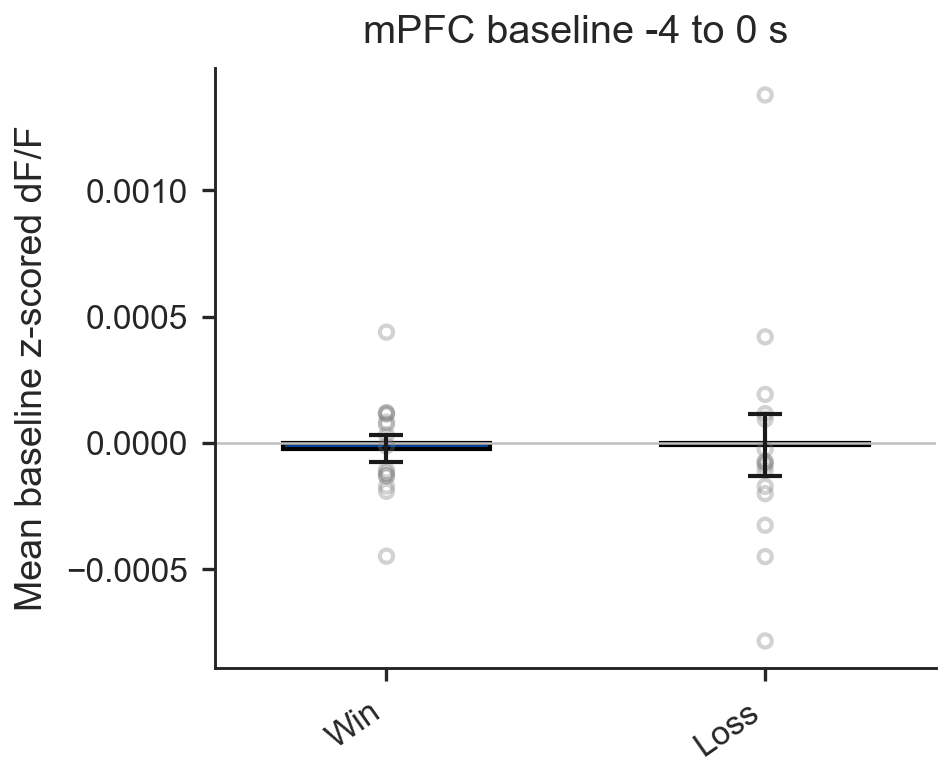

In [8]:
win_baseline = rsf.event_window_values_by_subject(
    rc_exp.winner_df,
    baseline_region,
    event_type=baseline_event,
    window=baseline_window,
)
loss_baseline = rsf.event_window_values_by_subject(
    rc_exp.loser_df,
    baseline_region,
    event_type=baseline_event,
    window=baseline_window,
)

fig, ax = plt.subplots(figsize=(3.1, 2.6))
rsf.plot_bar_groups(
    ax,
    [
        {"label": "Win", "values": win_baseline, "color": rsf.OUTCOME_COLORS["Win"]},
        {"label": "Loss", "values": loss_baseline, "color": rsf.OUTCOME_COLORS["Loss"]},
    ],
    "Mean baseline z-scored dF/F",
    f"{baseline_region} baseline {baseline_window[0]} to {baseline_window[1]} s",
)
plt.show()


## Optional: Save Pickles From Currently Loaded Objects

Use this only if you rebuilt objects elsewhere and want to refresh the pickles used by this notebook.

In [9]:
# saved_pickles = rsf.save_summary_pickles(
#     rt_exps,
#     rc_exp,
#     rt_pickle_paths=rt_pickle_paths,
#     rc_pickle_path=rc_pickle_paths[0],
# )
# saved_pickles
